# Tarea 3 – ML

**Javiera Rivas Parra**

En esta tarea trabajo con una base de la JUNAEB que reúne información de más de 41 mil estudiantes de educación parvularia. La base mezcla datos demográficos, de peso y talla, del entorno familiar y del comportamiento socioemocional de cada niño o niña. La pregunta que me guía durante todo el trabajo es si el perfil socioemocional del niño sirve para predecir la condición laboral de su madre (la variable `madre_work`).

Para responderla sigo el orden de un análisis completo. Primero exploro y limpio los datos, después resumo las variables socioemocionales con un análisis factorial (EFA y CFA), luego pruebo varios modelos de clasificación (Random Forest, XGBoost, SVM y Stacking) y al final armo grupos con clustering y entreno un modelo de texto sobre la variable narrative.

In [1]:
%pip install -q factor_analyzer xgboost nltk seaborn semopy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, re

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')

In [3]:
# Parche de compatibilidad sklearn/factor_analyzer
import sklearn.utils, sklearn.utils.validation as _skv

if not hasattr(_skv, '_orig_check_array'):
    _skv._orig_check_array = _skv.check_array

def _check_array_compat(*args, **kw):
    if 'force_all_finite' in kw:
        kw['ensure_all_finite'] = kw.pop('force_all_finite')
    return _skv._orig_check_array(*args, **kw)

_skv.check_array = _check_array_compat
sklearn.utils.check_array = _check_array_compat

## Pregunta 1

*Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.*

In [4]:
df = pd.read_csv('junaeb2n.csv')
print('Dimensiones:', df.shape)
df.head(3)

Dimensiones: (41854, 24)


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,narrative
0,1,85,0.75,1,1,1,1,1,2,1,2,2,1,2,2,2,3,2,NaN,0,11.0,11,-1,Las habilidades socioemocionales estan bien es...
1,0,76,0.71,0,1,1,1,1,1,1,1,4,1,1,1,1,1,1,5.0,0,8.0,8,1,"Exhibe un perfil socioemocional muy solido, si..."
2,1,68,0.27,0,1,2,2,3,2,1,2,3,2,2,3,2,1,3,NaN,1,13.0,13,1,"Su perfil socioemocional aun esta madurando, s..."


In [5]:
# Tipos de datos de cada columna de la base
print(df.dtypes.to_string())

sexo            int64
edad            int64
imce          float64
vive_padre      int64
vive_madre      int64
sk1             int64
sk2             int64
sk3             int64
sk4             int64
sk5             int64
sk6             int64
sk7             int64
sk8             int64
sk9             int64
sk10            int64
sk11            int64
sk12            int64
sk13            int64
act_fisica    float64
area            int64
educm         float64
educp           int64
madre_work      int64
narrative         str


La base tiene 41.854 filas y 24 columnas, y cada fila es un estudiante. Conviven varios tipos de variables: numéricas continuas como el `imce` o la edad, numéricas discretas como los ítems socioemocionales `sk1` a `sk13`, categóricas guardadas como números enteros (`sexo`, `area`, `vive_padre`, `vive_madre`, `madre_work`) y una variable de texto (`narrative`). Como las categóricas vienen codificadas con números, hay que tener cuidado de no tratarlas como si fueran cantidades. El tamaño de la muestra es grande, lo que ayuda a que los análisis sean estables, aunque después (en la Pregunta 3) eso mismo hará que el chi-cuadrado del CFA salga alto.

In [6]:
sk            = [f'sk{i}' for i in range(1, 14)]
categoricas   = ['sexo', 'area', 'vive_padre', 'vive_madre', 'madre_work']
cuantitativas = ['edad', 'imce', 'educm', 'educp', 'act_fisica']

miss = df.isna().sum()
pct = (miss / len(df) * 100).round(2)
print('Variables con datos faltantes:')
print(pd.concat([miss, pct], axis=1, keys=['n_faltantes', 'pct']).query('n_faltantes > 0'))

Variables con datos faltantes:
            n_faltantes   pct
act_fisica         1435  3.43
educm               551  1.32


Solo dos variables tienen datos faltantes que valga la pena mirar: `act_fisica` con cerca del 3,4% y `educm` con cerca del 1,3%. En los dos casos la pérdida es menor, así que se puede imputar sin deformar la distribución.

Elegí imputar con la mediana y no con la media por dos razones. La primera es que la mediana aguanta mejor los valores extremos, y variables como `act_fisica` o `imce` pueden estar algo sesgadas. La segunda es que así meto menos sesgo, sobre todo si los datos no faltan de forma totalmente aleatoria.

También pensé en borrar las filas con datos faltantes, pero eso significaría perder alrededor de 1.500 estudiantes completos sin necesidad, cuando la imputación por mediana es razonable y me deja la muestra entera para el clustering y la clasificación que vienen después.

In [7]:
print(df[cuantitativas].describe().T[['count','mean','std','min','25%','50%','75%','max']].round(2))
print()
for c in categoricas:
    print(f'-- {c} --')
    print(df[c].value_counts(dropna=False).sort_index().to_string(), '\n')

              count   mean   std    min   25%    50%    75%     max
edad        41854.0  83.07  3.99  62.00  81.0  82.00  84.00  107.00
imce        41854.0   1.01  1.38  -5.02   0.1   0.97   1.93    5.04
educm       41303.0  12.98  3.37   0.00  11.0  13.00  15.00   22.00
educp       41854.0  12.90  3.46   0.00  11.0  13.00  14.00   22.00
act_fisica  40419.0   2.55  1.07   1.00   2.0   2.00   3.00    5.00

-- sexo --
sexo
0    18737
1    23117 

-- area --
area
0     3699
1    38155 

-- vive_padre --
vive_padre
0    11733
1    30105
2       16 

-- vive_madre --
vive_madre
0     1529
1    40255
2       70 

-- madre_work --
madre_work
-1    17026
 0     4309
 1    20519 



En las variables numéricas, la edad se concentra cerca de los 83 meses (casi 7 años), que es lo esperable para este nivel, y con poca dispersión. El `imce` tiene media cercana a 1, así que en promedio esta población está un poco por encima del estándar de peso, lo que ya apunta a un sobrepeso leve. La escolaridad de la madre y del padre ronda los 13 años, o sea enseñanza media completa más o menos. La actividad física tiene media cerca de 2,5 en una escala de 1 a 5, lo que indica una frecuencia moderada.

En las categóricas, el sexo está bastante parejo entre niños y niñas y predomina la zona urbana. La variable `madre_work`, que es el target de la clasificación, viene desbalanceada: alrededor de un 40% es labor doméstica (-1), apenas un 10% es desempleada (0) y cerca de un 50% es empleada (1). Ese desbalance es el que me lleva, en la Pregunta 4, a sacar la categoría 0 (la minoritaria) y a mirar el ROC-AUC además del accuracy.

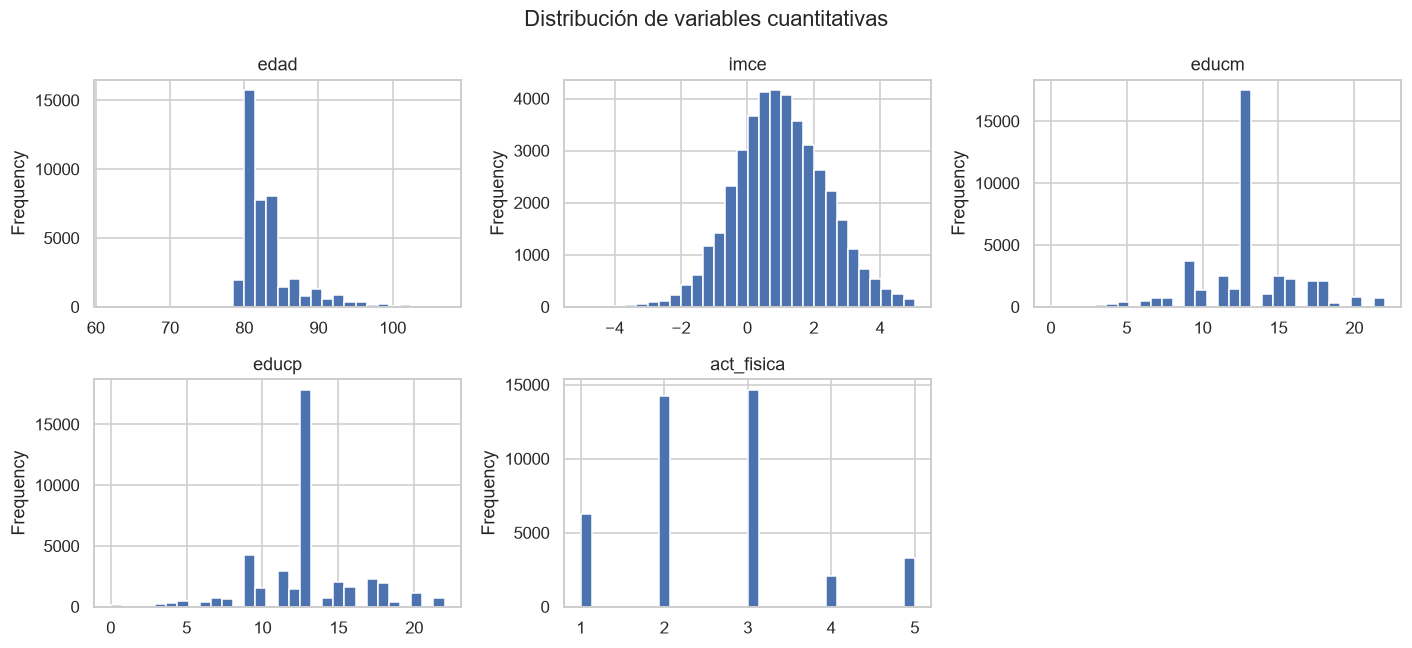

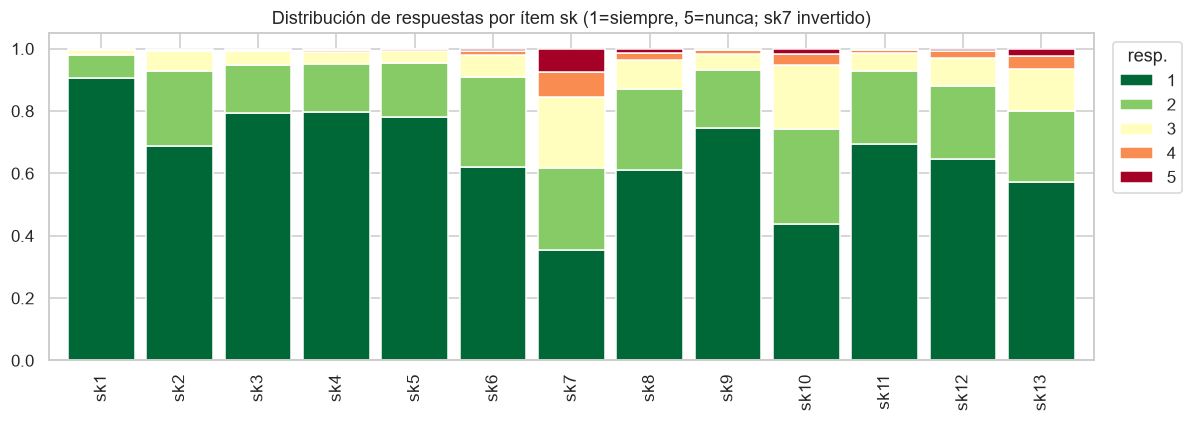

In [8]:
fig, ax = plt.subplots(2, 3, figsize=(13, 6))
for a, c in zip(ax.ravel(), cuantitativas):
    df[c].plot(kind='hist', bins=30, ax=a, color='#4C72B0', edgecolor='white')
    a.set_title(c)
ax.ravel()[-1].axis('off')
plt.suptitle('Distribución de variables cuantitativas'); plt.tight_layout(); plt.show()

prop = pd.concat([df[c].value_counts(normalize=True).sort_index().rename(c) for c in sk], axis=1).T
ax2 = prop.plot(kind='bar', stacked=True, figsize=(11, 4), colormap='RdYlGn_r', width=0.85)
ax2.set_title('Distribución de respuestas por ítem sk (1=siempre, 5=nunca; sk7 invertido)')
ax2.legend(title='resp.', bbox_to_anchor=(1.01, 1)); plt.tight_layout(); plt.show()

En los histogramas, la edad se ve aproximadamente normal y centrada en 83 meses. El `imce` tiene una cola larga hacia la derecha, con algunos valores muy altos que reviso enseguida. La escolaridad de la madre y del padre se parecen entre sí y se concentran alrededor de los 13 años, y la actividad física se acumula en los valores bajos de la escala.

En el gráfico de barras apiladas de los ítems `sk` se ve que la mayoría de las respuestas cae en los valores 1 y 2 (siempre o casi siempre), o sea que los niños tienden a mostrar buenas habilidades socioemocionales. De todos modos hay ítems con más respuestas intermedias que otros, lo que ya adelanta que no todos aportan lo mismo.

imce rango: -5.02 a 5.04
outliers por IQR: 426 (~1%) -> se retienen
implausibles |z|>5: 13 -> se winsorizan a +-5


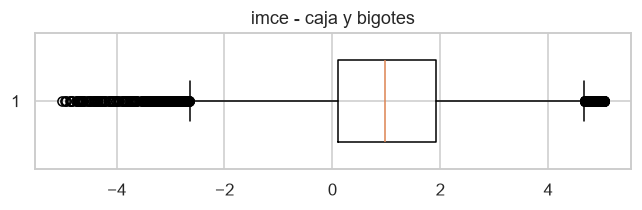

In [9]:
z = df['imce']
q1, q3 = z.quantile([.25, .75]); iqr = q3 - q1
print('imce rango:', round(z.min(), 2), 'a', round(z.max(), 2))
print('outliers por IQR:', int(((z < q1-1.5*iqr) | (z > q3+1.5*iqr)).sum()), '(~1%) -> se retienen')
print('implausibles |z|>5:', int((z.abs() > 5).sum()), '-> se winsorizan a +-5')

plt.figure(figsize=(7, 1.6))
plt.boxplot(df['imce'], vert=False, widths=0.6); plt.title('imce - caja y bigotes'); plt.show()

En el `imce` separo dos tipos de valores atípicos. Por un lado están los outliers según el criterio del IQR (como un 1% de los datos), que son valores lejos de la caja pero todavía posibles en la realidad: corresponden a casos de bajo peso u obesidad, con puntaje z entre más o menos -3 y 5. Esos los dejo, porque sacarlos correría la muestra hacia el centro y perdería casos reales. Por otro lado hay trece casos con un puntaje z mayor a 5 en valor absoluto, que para una variable estandarizada son imposibles, así que los acoto a ±5 con una winsorización. Es una corrección conservadora: mantiene la variación real de la población y solo arregla los valores que de verdad no tienen sentido.

In [10]:
df['act_fisica'] = df['act_fisica'].fillna(df['act_fisica'].median())
df['educm']      = df['educm'].fillna(df['educm'].median())
df['educp']      = df['educp'].fillna(df['educp'].median())
df['imce']       = df['imce'].clip(-5, 5)
assert df[cuantitativas].isna().sum().sum() == 0
print('Faltantes restantes:', int(df.isna().sum().sum()), '| filas:', len(df))

Faltantes restantes: 0 | filas: 41854


Después de imputar con la mediana y winsorizar el `imce`, la base queda sin datos faltantes en las variables numéricas y conserva las 41.854 filas originales. Así llego a las preguntas siguientes con la muestra completa.

Para el análisis factorial de las Preguntas 2 y 3 necesito que todos los ítems apunten en la misma dirección. Doce de ellos (sk1 a sk6 y sk8 a sk13) miden conductas positivas codificadas como 1=siempre hasta 5=nunca, así que un valor bajo es en realidad lo mejor. El `sk7` es distinto: mide agresividad, donde 1=nunca y 5=siempre, o sea va al revés de los demás.

Para ordenarlos aplico la transformación `6 - x` a todos y creo las variables `sk*_p`. Con esto un valor alto siempre significa más habilidad socioemocional (o menos agresividad, en el caso del sk7). Es un paso necesario para que las correlaciones y las cargas factoriales se puedan leer sin confundirse de signo.

Cuando miro las correlaciones de los ítems ya recodificados, salta que el `sk7` casi no se relaciona con el resto (alrededor de 0,09 en promedio, contra 0,24 a 0,31 de los demás). Esto me dice que la falta de agresividad no es simplemente lo contrario de tener buenas habilidades sociales, es otra cosa. Esa pista va a ser importante en la Pregunta 2, donde el `sk7` termina siendo el ítem que menos aporta.

Medias recodificadas (5 = mejor):
sk1_p     4.88
sk2_p     4.60
sk3_p     4.73
sk4_p     4.74
sk5_p     4.72
sk6_p     4.50
sk7_p     3.74
sk8_p     4.43
sk9_p     4.65
sk10_p    4.11
sk11_p    4.60
sk12_p    4.49
sk13_p    4.28 

Correlación promedio de cada ítem con el resto (más bajo = menos informativo):
sk7_p     0.089
sk12_p    0.236
sk13_p    0.237
sk8_p     0.238
sk10_p    0.243
sk6_p     0.252
sk1_p     0.257
sk3_p     0.267
sk5_p     0.274
sk9_p     0.276
sk4_p     0.297
sk2_p     0.297
sk11_p    0.314


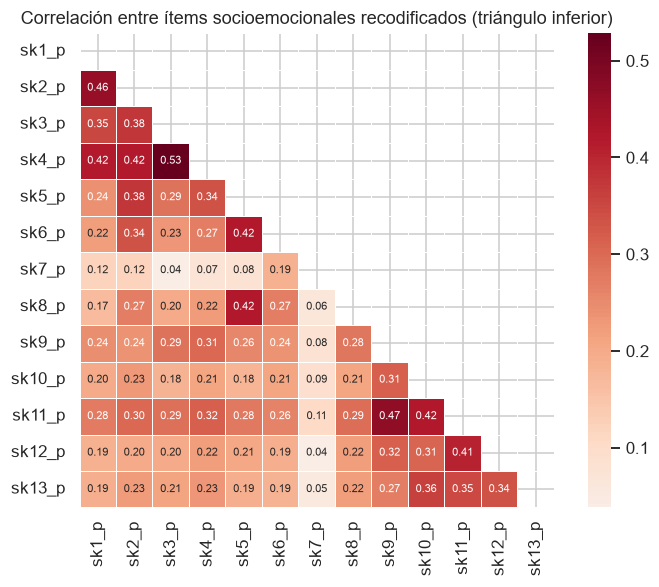

In [11]:
for c in sk:
    df[c + '_p'] = 6 - df[c]
sk_p = [c + '_p' for c in sk]

corr = df[sk_p].corr()
print('Medias recodificadas (5 = mejor):')
print(df[sk_p].mean().round(2).to_string(), '\n')

mc = ((corr.sum() - 1) / (len(sk_p) - 1)).sort_values()
print('Correlación promedio de cada ítem con el resto (más bajo = menos informativo):')
print(mc.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlación entre ítems socioemocionales recodificados (triángulo inferior)')
plt.tight_layout(); plt.show()

La matriz de correlaciones deja ver tres cosas. Primero, casi todos los ítems socioemocionales se correlacionan de forma moderada entre sí (entre 0,20 y 0,50 más o menos), lo que indica que comparten información y que tiene sentido hacer un análisis factorial. Segundo, el `sk7_p` se despega del resto con una correlación promedio muy baja (cerca de 0,089), lo que ya anticipa que se comporta distinto y probablemente no entra en las mismas dimensiones. Y tercero, no hay correlaciones exageradamente altas (sobre 0,90) que hagan pensar en problemas de multicolinealidad.

## Pregunta 2

*A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).*

In [12]:
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

X = df[sk_p].copy()
chi2, p_bart = calculate_bartlett_sphericity(X)
kmo_item, kmo_all = calculate_kmo(X)
print(f'Bartlett: chi2 = {chi2:,.0f}   p = {p_bart:.3g}')
print(f'KMO global: {kmo_all:.3f}\n')
print('KMO por ítem:')
print(pd.Series(kmo_item, index=sk_p).round(3).sort_values().to_string())

Bartlett: chi2 = 122,117   p = 0
KMO global: 0.873

KMO por ítem:
sk7_p     0.788
sk5_p     0.845
sk4_p     0.859
sk3_p     0.861
sk1_p     0.870
sk8_p     0.873
sk6_p     0.875
sk11_p    0.876
sk10_p    0.879
sk2_p     0.881
sk13_p    0.894
sk12_p    0.895
sk9_p     0.898


El test de Bartlett da significativo (p < 0,001), o sea que las correlaciones entre ítems no son producto del azar y el análisis factorial tiene sentido. El KMO global es de alrededor de 0,87, que se considera una muy buena adecuación de la muestra, y todos los KMO por ítem superan 0,79, así que ninguno se ve inadecuado de entrada. Si saco el `sk7` más adelante va a ser por sus cargas, no por un problema de adecuación muestral.

Autovalores reales : [4.154 1.337 1.099 0.999 0.772 0.701 0.692 0.684 0.597 0.516 0.506 0.487
 0.456]
Paralelo (p95 ruido): [1.035 1.027 1.021 1.016 1.011 1.007 1.003 0.999 0.995 0.991 0.987 0.981
 0.977]
Kaiser  (autovalor > 1)        : 3
Análisis paralelo (real > ruido): 3

Varianza acumulada por nro de factores:
  k=1: 0.265
  k=2: 0.310
  k=3: 0.348
  k=4: 0.352
  k=5: 0.353


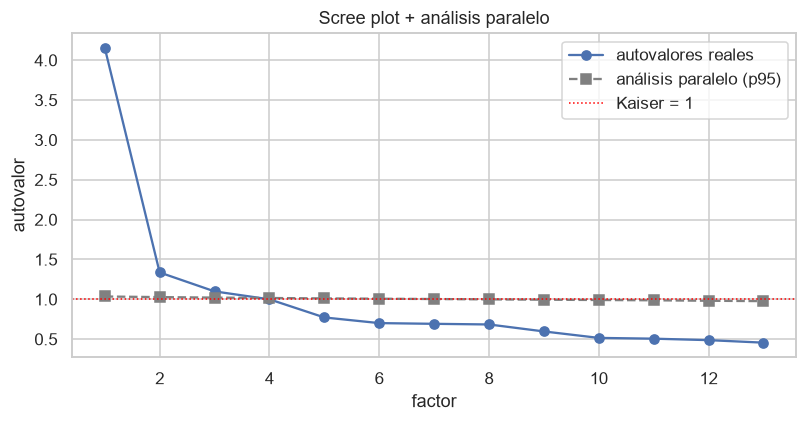

In [13]:
fa = FactorAnalyzer(n_factors=len(sk_p), rotation=None).fit(X)
eig, _ = fa.get_eigenvalues()

n, m = X.shape
rng = np.random.default_rng(RANDOM_STATE)
rand_eig = np.array([np.sort(np.linalg.eigvalsh(np.corrcoef(rng.normal(size=(n, m)), rowvar=False)))[::-1]
                     for _ in range(100)])
pa95 = np.percentile(rand_eig, 95, axis=0)

print('Autovalores reales :', np.round(eig, 3))
print('Paralelo (p95 ruido):', np.round(pa95, 3))
print('Kaiser  (autovalor > 1)        :', int((eig > 1).sum()))
print('Análisis paralelo (real > ruido):', int((eig > pa95).sum()))

print('\nVarianza acumulada por nro de factores:')
for k in range(1, 6):
    fk = FactorAnalyzer(n_factors=k, rotation='oblimin').fit(X)
    print(f'  k={k}: {fk.get_factor_variance()[2][-1]:.3f}')

plt.figure(figsize=(7.5, 4))
plt.plot(range(1, m+1), eig, 'o-', label='autovalores reales')
plt.plot(range(1, m+1), pa95, 's--', color='grey', label='análisis paralelo (p95)')
plt.axhline(1, color='red', ls=':', lw=1, label='Kaiser = 1')
plt.xlabel('factor'); plt.ylabel('autovalor'); plt.title('Scree plot + análisis paralelo')
plt.legend(); plt.tight_layout(); plt.show()

El criterio de Kaiser y el análisis paralelo coinciden en lo mismo, tres factores. Los tres primeros autovalores (4,15, 1,34 y 1,10) quedan claramente por encima del ruido que genera el análisis paralelo, mientras que el cuarto se queda en 0,999, justo por debajo, y la varianza acumulada casi no sube al agregar más factores. Que los dos criterios apunten al mismo número me da confianza para quedarme con tres, que además es la opción más fácil de interpretar.

In [14]:
LABELS = {'sk1_p':'afecto a padres','sk2_p':'afecto a pares','sk3_p':'expresa sentimientos',
          'sk4_p':'gestos de sentimientos','sk5_p':'juega con otros','sk6_p':'comparte sus cosas',
          'sk7_p':'no agresivo','sk8_p':'juegos grupales','sk9_p':'pregunta a adultos',
          'sk10_p':'interés por libros','sk11_p':'interés por su entorno','sk12_p':'arma/desarma',
          'sk13_p':'expresiones artísticas'}

efa = FactorAnalyzer(n_factors=3, rotation='oblimin').fit(X)
load = pd.DataFrame(efa.loadings_, index=sk_p, columns=['F1','F2','F3'])
load.insert(0, 'ítem', [LABELS[i] for i in sk_p])
load['comunalidad'] = efa.get_communalities()
dom = load[['F1','F2','F3']].abs()
load['factor'] = np.where(dom.max(axis=1) >= 0.30, dom.idxmax(axis=1), 'ninguno')
print('Cargas factoriales (rotación oblimin):')
print(load.round(3).to_string())

Cargas factoriales (rotación oblimin):
                          ítem     F1     F2     F3  comunalidad   factor
sk1_p          afecto a padres  0.026  0.604 -0.024        0.366       F2
sk2_p           afecto a pares -0.002  0.510  0.215        0.306       F2
sk3_p     expresa sentimientos  0.023  0.653 -0.028        0.427       F2
sk4_p   gestos de sentimientos  0.004  0.736 -0.011        0.542       F2
sk5_p          juega con otros -0.034  0.023  0.780        0.611       F3
sk6_p       comparte sus cosas  0.082  0.077  0.464        0.228       F3
sk7_p              no agresivo  0.042  0.039  0.122        0.018  ninguno
sk8_p          juegos grupales  0.220 -0.078  0.461        0.267       F3
sk9_p       pregunta a adultos  0.503  0.087  0.054        0.263       F1
sk10_p      interés por libros  0.618 -0.033 -0.025        0.383       F1
sk11_p  interés por su entorno  0.696  0.038  0.013        0.486       F1
sk12_p            arma/desarma  0.577 -0.029  0.000        0.334       F1

La rotación oblicua deja una estructura bastante limpia, sin cargas cruzadas que molesten, y separa tres dimensiones: una de curiosidad o interés cognitivo, una de vínculo afectivo y otra de interacción social. El único ítem que no calza es el `sk7`: su comunalidad es de apenas 0,02 y no carga fuerte en ningún factor. Esto ya se venía venir desde la Pregunta 1 por su baja correlación (0,089). Por eso lo dejo fuera del modelo. Tiene sentido, que un niño no sea agresivo no implica directamente que tenga mejores habilidades socioemocionales, es algo que se mide aparte.

In [15]:
factor_items = {
    'F1_cognitivo': ['sk9_p','sk10_p','sk11_p','sk12_p','sk13_p'],
    'F2_afectivo':  ['sk1_p','sk2_p','sk3_p','sk4_p'],
    'F3_social':    ['sk5_p','sk6_p','sk8_p'],
}
sk_cfa = [it for grp in factor_items.values() for it in grp]
print('Ítems que pasan al CFA (sk7 excluido):', len(sk_cfa))
for f, its in factor_items.items():
    print(f'  {f}: {[LABELS[i] for i in its]}')

Ítems que pasan al CFA (sk7 excluido): 12
  F1_cognitivo: ['pregunta a adultos', 'interés por libros', 'interés por su entorno', 'arma/desarma', 'expresiones artísticas']
  F2_afectivo: ['afecto a padres', 'afecto a pares', 'expresa sentimientos', 'gestos de sentimientos']
  F3_social: ['juega con otros', 'comparte sus cosas', 'juegos grupales']


En resumen, el EFA con rotación oblimin deja tres factores bien diferenciados, que leo como curiosidad cognitiva, vínculo afectivo e interacción social. El `sk7` (agresividad) no entra en esa estructura, con una comunalidad de 0,02, así que lo saco antes de pasar al modelo confirmatorio. Los doce ítems que quedan se reparten de forma ordenada entre los tres factores, sin cargas cruzadas problemáticas, lo que me deja en buen pie para el CFA.

## Pregunta 3

*Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). Guarde sus predicciones.*

In [16]:
import semopy

FACTOR_NAMES = {'Curiosidad': 'Curiosidad e intereses cognitivos',
                'Afectivo':   'Vínculo afectivo-emocional',
                'Social':     'Interacción social y juego'}

spec = """
Curiosidad =~ sk9_p + sk10_p + sk11_p + sk12_p + sk13_p
Afectivo   =~ sk1_p + sk2_p + sk3_p + sk4_p
Social     =~ sk5_p + sk6_p + sk8_p
"""
cfa = semopy.Model(spec)
cfa.fit(df)
est = cfa.inspect(std_est=True)

fit = semopy.calc_stats(cfa).T
print('Índices de ajuste:')
for k in ['chi2','DoF','CFI','TLI','RMSEA','GFI']:
    if k in fit.index:
        print(f'  {k:6s} = {float(fit.loc[k].iloc[0]):.4f}')

Índices de ajuste:
  chi2   = 6148.0964
  DoF    = 51.0000
  CFI    = 0.9492
  TLI    = 0.9342
  RMSEA  = 0.0534
  GFI    = 0.9488


El ajuste del modelo confirmatorio sale bien según los criterios habituales. El CFI queda cerca de 0,95 y el TLI cerca de 0,93, los dos por encima de los umbrales que se suelen pedir. El RMSEA es de alrededor de 0,053, que también está en el rango aceptable (bajo 0,06). El chi-cuadrado sale muy alto, pero eso es lo esperable con una muestra de más de 41 mil casos: con tantos datos, hasta diferencias mínimas respecto del modelo perfecto salen significativas, así que en este caso no lo tomo como una mala señal.

In [17]:
load_cfa = est[est['op'] == '~'][['lval','rval','Est. Std','p-value']].copy()
load_cfa.columns = ['ítem','factor','carga_std','p']
load_cfa['ítem'] = load_cfa['ítem'].map(LABELS)
load_cfa['factor'] = load_cfa['factor'].map(FACTOR_NAMES)
load_cfa = load_cfa.sort_values(['factor','carga_std'], ascending=[True,False])
print('Importancia de cada medida (carga estandarizada):')
print(load_cfa.to_string(index=False))

Importancia de cada medida (carga estandarizada):
                  ítem                            factor  carga_std    p
interés por su entorno Curiosidad e intereses cognitivos   0.736351  0.0
    pregunta a adultos Curiosidad e intereses cognitivos   0.607747    -
    interés por libros Curiosidad e intereses cognitivos   0.564699  0.0
          arma/desarma Curiosidad e intereses cognitivos   0.550577  0.0
expresiones artísticas Curiosidad e intereses cognitivos   0.523010  0.0
       juega con otros        Interacción social y juego   0.722617    -
    comparte sus cosas        Interacción social y juego   0.571765  0.0
       juegos grupales        Interacción social y juego   0.559446  0.0
gestos de sentimientos        Vínculo afectivo-emocional   0.715462  0.0
        afecto a pares        Vínculo afectivo-emocional   0.652106  0.0
  expresa sentimientos        Vínculo afectivo-emocional   0.646142  0.0
       afecto a padres        Vínculo afectivo-emocional   0.599986    -


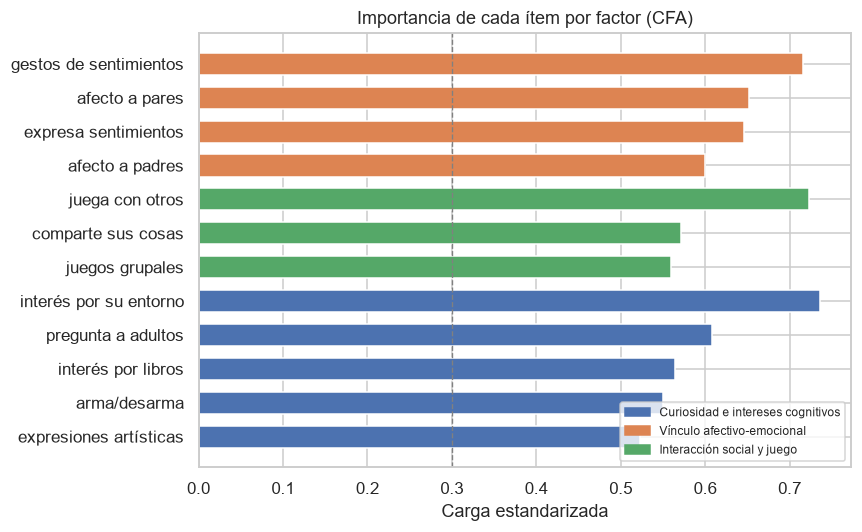

In [18]:
colores_factor = {
    'Curiosidad e intereses cognitivos': '#4C72B0',
    'Vínculo afectivo-emocional':        '#DD8452',
    'Interacción social y juego':        '#55A868',
}

orden = load_cfa.sort_values(['factor', 'carga_std'], ascending=[True, True])
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(orden['ítem'], orden['carga_std'],
               color=[colores_factor[f] for f in orden['factor']],
               edgecolor='white', height=0.65)
ax.axvline(0.3, color='grey', linestyle='--', linewidth=0.9, label='umbral 0.3')
ax.set_xlabel('Carga estandarizada')
ax.set_title('Importancia de cada ítem por factor (CFA)')
from matplotlib.patches import Patch
leyenda = [Patch(color=v, label=k) for k, v in colores_factor.items()]
ax.legend(handles=leyenda, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

Todas las cargas son altas y significativas, lo que confirma que los ítems sí están midiendo las dimensiones que propuse. Las cargas más fuertes son las del interés por el entorno (0,74), los gestos de afecto (0,72) y el juego con otros (0,72), que son los mejores representantes de cada factor. Que las cargas del EFA y del CFA coincidan bastante refuerza que la estructura de tres factores es sólida.

In [19]:
facs = list(FACTOR_NAMES)
cov = est[(est['op']=='~~') & (est['lval'].isin(facs)) & (est['rval'].isin(facs))]
R = pd.DataFrame(np.eye(3), index=facs, columns=facs)
for _, r in cov.iterrows():
    R.loc[r['lval'], r['rval']] = R.loc[r['rval'], r['lval']] = float(r['Est. Std'])
R.index = R.columns = [FACTOR_NAMES[f] for f in facs]
print('Correlación entre factores:')
print(R.round(3).to_string())

Correlación entre factores:
                                   Curiosidad e intereses cognitivos  Vínculo afectivo-emocional  Interacción social y juego
Curiosidad e intereses cognitivos                              1.000                       0.612                       0.596
Vínculo afectivo-emocional                                     0.612                       1.000                       0.658
Interacción social y juego                                     0.596                       0.658                       1.000


Los factores se correlacionan entre 0,60 y 0,66, siendo el vínculo afectivo y la interacción social los más parecidos entre sí. Son correlaciones lo bastante altas como para pensar que hay un rasgo socioemocional general por debajo, pero no tan altas como para juntar todo en un solo factor. Tener tres factores relacionados pero distinguibles calza bien con lo que se espera del desarrollo socioemocional a esta edad.

In [20]:
scores = cfa.predict_factors(df)
SCORE_COLS = {'Curiosidad':'sc_curiosidad','Afectivo':'sc_afectivo','Social':'sc_social'}
scores = scores.rename(columns=SCORE_COLS)
df[list(SCORE_COLS.values())] = scores[list(SCORE_COLS.values())].values
features_cfa = list(SCORE_COLS.values())
print('Puntajes factoriales guardados:', features_cfa)
print(df[features_cfa].describe().round(3).T.to_string())

Puntajes factoriales guardados: ['sc_curiosidad', 'sc_afectivo', 'sc_social']
                 count  mean    std    min    25%    50%    75%    max
sc_curiosidad  41854.0  -0.0  0.367 -2.767 -0.179  0.112  0.275  0.353
sc_afectivo    41854.0  -0.0  0.214 -2.020 -0.066  0.084  0.145  0.160
sc_social      41854.0  -0.0  0.356 -3.001 -0.151  0.126  0.269  0.308


El CFA confirma la estructura de tres factores con doce ítems que venía del EFA. Los índices de ajuste son buenos, las cargas son altas y significativas, y las correlaciones entre factores muestran una relación moderada. Guardo los puntajes factoriales que predice el modelo (`sc_curiosidad`, `sc_afectivo`, `sc_social`) para usarlos como variables predictoras en las preguntas de clasificación.

## Pregunta 4

*Usando los features del modelo de la Pregunta 3, entrene un modelo Random Forest para clasificar la muestra usando la variable madre_work como target. Para facilitar el problema, excluya las personas desempleadas (categoria minoritaria). Recuerde tanto la optimizacion de hiperpametros como la validacion de pliegues (k-fold).*

In [21]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay, roc_curve)

modelo_df = df[df['madre_work'] != 0].copy()
X = modelo_df[features_cfa]
y = (modelo_df['madre_work'] == 1).astype(int)     # 1 = empleada, 0 = labor doméstica
print('N =', len(modelo_df), '| % empleada =', round(y.mean(), 3),
      '| baseline (clase mayoritaria) =', round(max(y.mean(), 1 - y.mean()), 3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

N = 37545 | % empleada = 0.547 | baseline (clase mayoritaria) = 0.547


In [22]:
resultados = []

def evaluar(nombre, modelo, t_fit, X_te=None, y_te=None, plot=True):
    Xt = X_test if X_te is None else X_te
    yt = y_test if y_te is None else y_te
    pred = modelo.predict(Xt)
    score = (modelo.predict_proba(Xt)[:, 1] if hasattr(modelo, 'predict_proba')
             else modelo.decision_function(Xt))
    acc = accuracy_score(yt, pred)
    auc = roc_auc_score(yt, score)
    resultados.append({'modelo': nombre, 'accuracy': acc, 'AUC': auc, 't_fit_s': round(t_fit, 3)})
    print(f'{nombre:22s}  acc={acc:.4f}  AUC={auc:.4f}  t_fit={t_fit:.2f}s')
    print(classification_report(yt, pred, target_names=['labor dom.', 'empleada']))
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
        ConfusionMatrixDisplay(confusion_matrix(yt, pred),
            display_labels=['labor dom.', 'empleada']).plot(cmap='Blues', colorbar=False, ax=axes[0])
        axes[0].set_title(f'Confusión - {nombre}')
        fpr, tpr, _ = roc_curve(yt, score)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.4f}')
        axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
        axes[1].set(xlabel='FPR', ylabel='TPR', title=f'ROC - {nombre}')
        axes[1].legend(loc='lower right')
        plt.tight_layout(); plt.show()
    return pred

GridSearch RF en 22.5s
Mejores hiperparámetros: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 400}
AUC validación (5-fold): 0.5241
Random Forest           acc=0.5536  AUC=0.5254  t_fit=2.27s
              precision    recall  f1-score   support

  labor dom.       0.57      0.06      0.11      3405
    empleada       0.55      0.96      0.70      4104

    accuracy                           0.55      7509
   macro avg       0.56      0.51      0.41      7509
weighted avg       0.56      0.55      0.43      7509



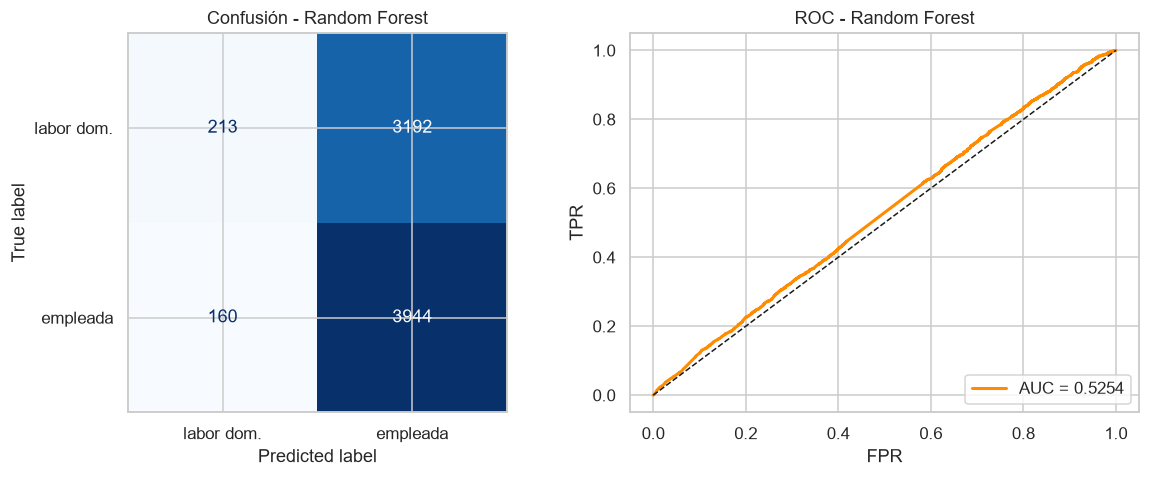

In [23]:
grid_rf = {'n_estimators': [400], 'max_depth': [8], 'min_samples_leaf': [10], 'max_features': ['sqrt']}
t = time.time()
gs_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
                     grid_rf, cv=cv, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)
print(f'GridSearch RF en {time.time()-t:.1f}s')
print('Mejores hiperparámetros:', gs_rf.best_params_)
print(f'AUC validación (5-fold): {gs_rf.best_score_:.4f}')

rf_best = gs_rf.best_estimator_
t = time.time(); rf_best.fit(X_train, y_train); t_rf = time.time() - t
pred_rf = evaluar('Random Forest', rf_best, t_rf)

El Random Forest, con los hiperparámetros que eligió el GridSearch, no logra separar a las madres en labor doméstica de las empleadas. El AUC queda en torno a 0,52 y el accuracy cerca de 0,55, o sea prácticamente igual al baseline. En la práctica el modelo termina marcando casi todo como "empleada" porque es la clase más frecuente. La validación cruzada confirma lo mismo, así que no es un problema de mala suerte al partir los datos. Lo que pasa es que el perfil socioemocional del niño simplemente no tiene información suficiente sobre la situación laboral de su madre.

## Pregunta 5

*Compare los resultados de la Pregunta 4 usando los modelos XGBoost, Support Vector Machine y Stacking. Discuta sus resultados respecto de la parte 5, tanto en la matriz de confusion, como la eficiencia (velocidad de computo).*

GridSearch XGBoost en 7.6s
Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
AUC validación (5-fold): 0.5214
XGBoost                 acc=0.5517  AUC=0.5268  t_fit=0.53s
              precision    recall  f1-score   support

  labor dom.       0.53      0.09      0.15      3405
    empleada       0.55      0.94      0.70      4104

    accuracy                           0.55      7509
   macro avg       0.54      0.51      0.42      7509
weighted avg       0.54      0.55      0.45      7509



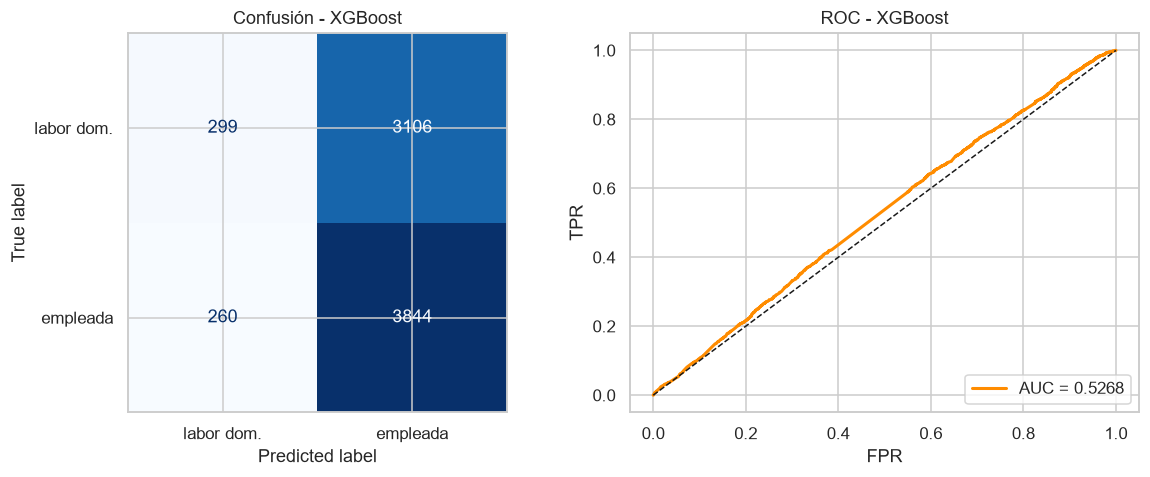

In [24]:
from xgboost import XGBClassifier

grid_xgb = {'n_estimators': [200], 'max_depth': [3], 'learning_rate': [0.05], 'subsample': [0.8]}
t = time.time()
gs_xgb = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1),
    grid_xgb, cv=cv, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)
t_xgb_gs = time.time() - t
print(f'GridSearch XGBoost en {t_xgb_gs:.1f}s')
print('Mejores hiperparámetros:', gs_xgb.best_params_)
print(f'AUC validación (5-fold): {gs_xgb.best_score_:.4f}')

xgb_best = gs_xgb.best_estimator_
t = time.time(); xgb_best.fit(X_train, y_train); t_xgb = time.time() - t
pred_xgb = evaluar('XGBoost', xgb_best, t_xgb)

GridSearch SVC en 2.9s

Mejores hiperparámetros: {'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
AUC validación (5-fold en submuestra): 0.5398

SVC                     acc=0.5521  AUC=0.5344  t_fit=37.18s
              precision    recall  f1-score   support

  labor dom.       0.57      0.05      0.09      3405
    empleada       0.55      0.97      0.70      4104

    accuracy                           0.55      7509
   macro avg       0.56      0.51      0.40      7509
weighted avg       0.56      0.55      0.43      7509



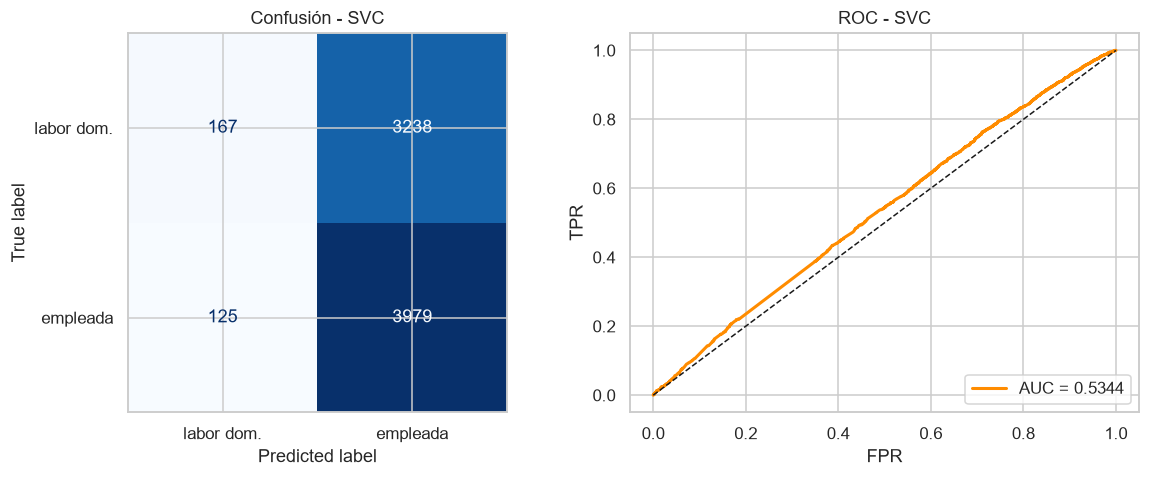

In [25]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# Para SVM, GridSearchCV en 30,000 datos toma mucho tiempo.
# 1. Quitamos probability=True (ROC_AUC usará decision_function).
# 2. Hacemos la búsqueda de hiperparámetros en una submuestra (ej. 5000 datos).
pipe_svc = Pipeline([('scaler', StandardScaler()),
                     ('svc', SVC(random_state=RANDOM_STATE))])
grid_svc = {'svc__C': [0.1], 'svc__kernel': ['rbf'], 'svc__gamma': ['scale']}

X_sub, y_sub = resample(X_train, y_train, n_samples=5000, random_state=RANDOM_STATE, stratify=y_train)

t = time.time()
gs_svc = GridSearchCV(pipe_svc, grid_svc, cv=cv, scoring='roc_auc', n_jobs=-1
                      ).fit(X_sub, y_sub)
t_svc_gs = time.time() - t
print(f'GridSearch SVC en {t_svc_gs:.1f}s\n')
print('Mejores hiperparámetros:', gs_svc.best_params_)
print(f'AUC validación (5-fold en submuestra): {gs_svc.best_score_:.4f}\n')

# Entrenamos el mejor modelo con TODOS los datos
svc_best = gs_svc.best_estimator_
t = time.time(); svc_best.fit(X_train, y_train); t_svc = time.time() - t
pred_svc = evaluar('SVC', svc_best, t_svc)

El Stacking junta los tres modelos anteriores como base y usa unregresión logística como modelo final que combina sus predicciones. La idea es que si cada modelo captara una parte distinta de la señal, juntarlos debería ayudar. El detalle es que cuando los modelos base rinden parecido y la señal es débil, el Stacking casi nunca mejora mucho.

Stacking                acc=0.5512  AUC=0.5293  t_fit=90.34s
              precision    recall  f1-score   support

  labor dom.       0.55      0.06      0.10      3405
    empleada       0.55      0.96      0.70      4104

    accuracy                           0.55      7509
   macro avg       0.55      0.51      0.40      7509
weighted avg       0.55      0.55      0.43      7509



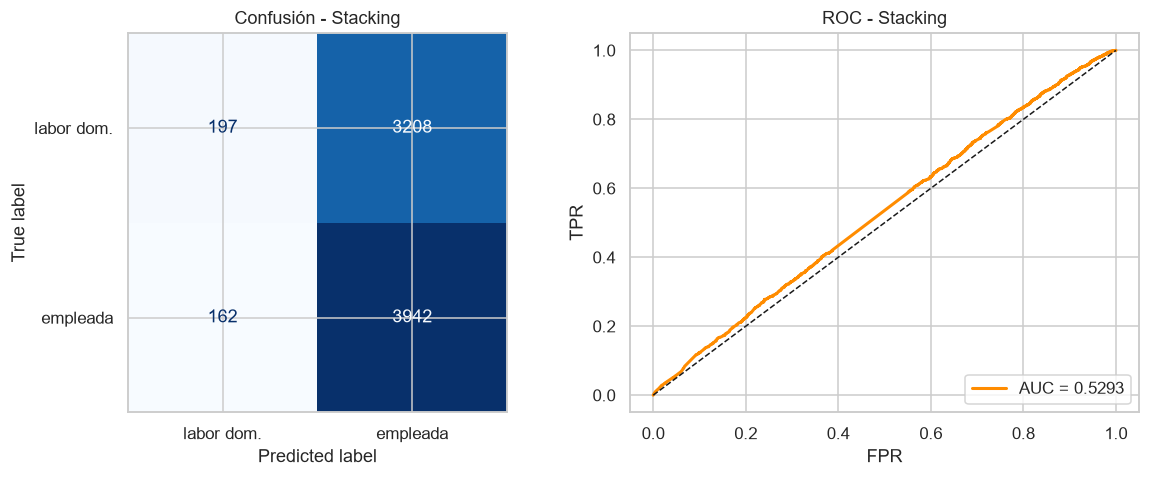

In [26]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking = StackingClassifier(
    estimators=[('rf', rf_best), ('xgb', xgb_best), ('svc', svc_best)],
    final_estimator=LogisticRegression(random_state=RANDOM_STATE),
    cv=5, n_jobs=-1)
t = time.time(); stacking.fit(X_train, y_train); t_stack = time.time() - t
pred_stack = evaluar('Stacking', stacking, t_stack)

=== Comparación de modelos ===
       modelo  accuracy      AUC  t_fit_s
          SVC  0.552137 0.534371   37.183
     Stacking  0.551205 0.529304   90.339
      XGBoost  0.551738 0.526810    0.528
Random Forest  0.553602 0.525362    2.271

Mejor modelo por AUC: SVC


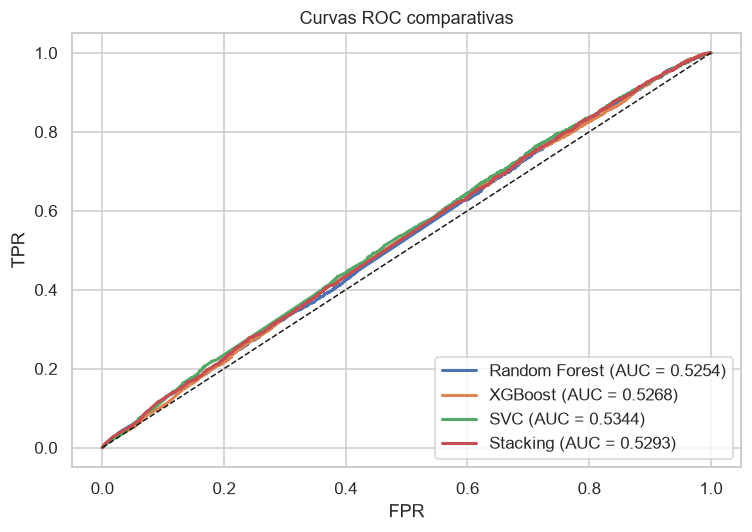

In [27]:
comp = pd.DataFrame(resultados).sort_values('AUC', ascending=False).reset_index(drop=True)
print('=== Comparación de modelos ===')
print(comp.to_string(index=False))

mejor_nombre = comp.loc[comp['AUC'].idxmax(), 'modelo']
modelos_dict = {'Random Forest': rf_best, 'XGBoost': xgb_best,
                'SVC': svc_best, 'Stacking': stacking}
mejor_modelo = modelos_dict[mejor_nombre]
print(f'\nMejor modelo por AUC: {mejor_nombre}')

# Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in modelos_dict.items():
    s = (model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba')
         else model.decision_function(X_test))
    fpr, tpr, _ = roc_curve(y_test, s)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc_score(y_test, s):.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set(xlabel='FPR', ylabel='TPR', title='Curvas ROC comparativas')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

Ninguno de los cuatro modelos se despega del azar. Los AUC quedan todos apretados entre 0,52 y 0,53 y los accuracy se mantienen cerca de 0,55, así que las diferencias entre ellos son básicamente ruido.

Lo interesante es mirar la matriz de confusión, porque explica de dónde sale ese 0,55. Los modelos aciertan casi todas las "empleada" (el recall de esa clase es altísimo, sobre 0,95) pero fallan casi todas las "labor doméstica" (recall muy bajo, del orden de 0,05). O sea, no es que estén distinguiendo bien: aprendieron a marcar a casi todos como "empleada", que es la clase mayoritaria, y con eso consiguen un accuracy parecido al baseline. Por eso casi todos los errores son del mismo tipo, madres en labor doméstica clasificadas como empleadas (falsos positivos de "empleada"). Y esto pasa igual en los cuatro modelos.

Donde sí hay diferencias claras es en el tiempo de cómputo. XGBoost entrena en una fracción de segundo, el Random Forest en pocos segundos, el SVM es bastante más lento (su tiempo crece feo con la cantidad de datos) y el Stacking es el más caro de todos, porque entrena a los tres modelos base más el meta-modelo con validación interna. Si el rendimiento es prácticamente igual, me quedaría con XGBoost por ser el más rápido. Pero la conclusión de fondo no cambia: ningún modelo puede inventar una señal que los datos no tienen.

## Pregunta 6

*Utilice alguno de los metodos de clustering vistos en clases para generar grupos en base a las variables IMCE y actividad fisica. Que puede concluir de los resultados?*

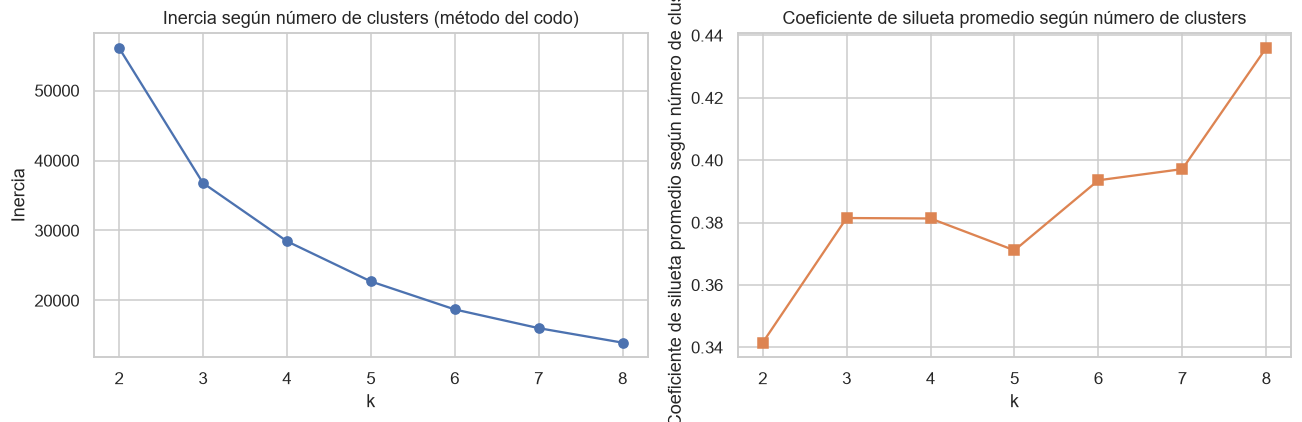

k seleccionado (codo + parsimonia): 3  (silueta = 0.381)


In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

vars_cluster = ['imce', 'act_fisica']
scaler_cl = StandardScaler()
X_cl = scaler_cl.fit_transform(df[vars_cluster])

K_range = range(2, 9)
inercias, siluetas = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cl)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_cl, labels, sample_size=10000, random_state=RANDOM_STATE))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inercias, 'o-', color='#4C72B0')
ax1.set_xlabel('k'); ax1.set_ylabel('Inercia'); ax1.set_title('Inercia según número de clusters (método del codo)')
ax2.plot(K_range, siluetas, 's-', color='#DD8452')
ax2.set_xlabel('k'); ax2.set_ylabel('Coeficiente de silueta promedio según número de clusters'); ax2.set_title('Coeficiente de silueta promedio según número de clusters')
plt.tight_layout(); plt.show()

k_opt = 3
print(f'k seleccionado (codo + parsimonia): {k_opt}  (silueta = {siluetas[k_opt - 2]:.3f})')

El método del codo muestra una caída fuerte de la inercia al pasar de dos a tres clusters, y después la curva se aplana. El coeficiente de silueta da un salto en k=3 y se queda en una meseta para los valores siguientes, sin que ningún k cercano lo mejore de forma importante. Por eso, y porque tres grupos son fáciles de interpretar, me quedo con k_opt = 3, que además coincide con el codo de la curva de inercia.

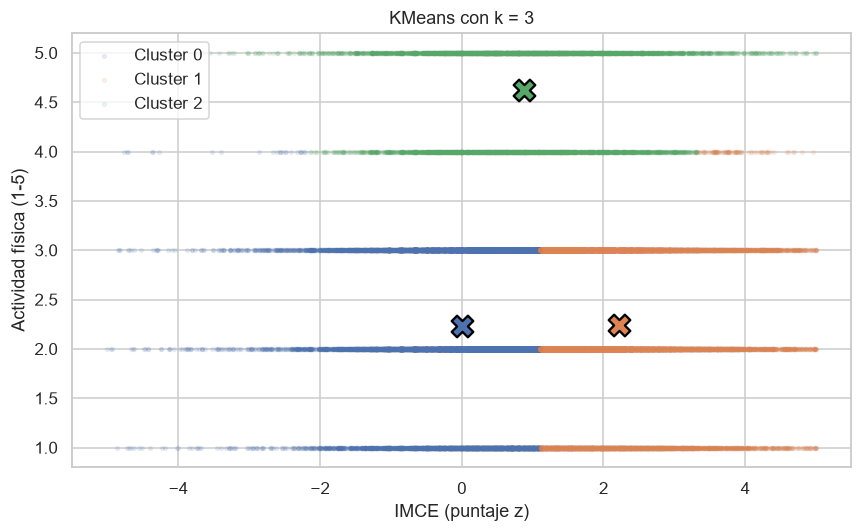

Perfil de cada cluster:
         imce_mean  imce_count  act_fisica_mean  act_fisica_count  madre_work_mean  madre_work_count
cluster                                                                                             
0             0.00       19595             2.23             19595             0.08             19595
1             2.22       17026             2.24             17026             0.10             17026
2             0.89        5233             4.62              5233             0.02              5233

Cluster con mayor IMCE promedio: 1 (IMCE medio = 2.22, n = 17026)


In [29]:
km_final = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = km_final.fit_predict(X_cl)

fig, ax = plt.subplots(figsize=(8, 5))
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#DA8BC3']
for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'imce'], df.loc[mask, 'act_fisica'],
               alpha=0.10, s=6, color=colores[c % len(colores)], label=f'Cluster {c}')
    ax.scatter(df.loc[mask, 'imce'].mean(), df.loc[mask, 'act_fisica'].mean(),
               marker='X', s=200, color=colores[c % len(colores)], edgecolor='black', linewidth=1.5)
ax.set_xlabel('IMCE (puntaje z)'); ax.set_ylabel('Actividad física (1-5)')
ax.set_title(f'KMeans con k = {k_opt}'); ax.legend()
plt.tight_layout(); plt.show()

perfil = df.groupby('cluster')[vars_cluster + ['madre_work']].agg(['mean', 'count'])
perfil.columns = [f'{v}_{s}' for v, s in perfil.columns]
print('Perfil de cada cluster:')
print(perfil.round(2).to_string())

cluster_imce_alto = df.groupby('cluster')['imce'].mean().idxmax()
imce_medio = df.groupby('cluster')['imce'].mean().max()
n_alto = (df['cluster'] == cluster_imce_alto).sum()
print(f'\nCluster con mayor IMCE promedio: {cluster_imce_alto}'
      f' (IMCE medio = {imce_medio:.2f}, n = {n_alto})')

Los tres clusters separan a la población de una forma que calza con lo que uno esperaría entre actividad física e IMCE. El grupo más numeroso junta a niños de peso normal y poca actividad física (IMCE cercano a 0). Un segundo grupo, también de poca actividad, reúne a los niños con sobrepeso, con un IMCE claramente alto (alrededor de 2,2). Y el tercero, más chico, agrupa a niños muy activos cuyo IMCE, aunque positivo, es más bajo que el del grupo con sobrepeso. Esto va en la línea de que más actividad física se asocia con menos peso, aunque como son datos de un solo momento en el tiempo hablo de asociación y no de causa. Además, que incluso los niños más activos tengan IMCE positivo refleja el sesgo general de la población hacia el sobrepeso que ya había aparecido en la Pregunta 1.

## Pregunta 7

*Elija el grupo con mayor IMCE promedio en base a la Pregunta 6. Estime nuevamente su mejor modelo de la Pregunta 5. Que puede concluir de sus resultados?*

Submuestra Q7: n = 15225, % empleada = 0.558
Modelo a re-entrenar: SVC
SVC (IMCE alto)         acc=0.5599  AUC=0.5385  t_fit=8.79s
              precision    recall  f1-score   support

  labor dom.       0.52      0.04      0.08      1345
    empleada       0.56      0.97      0.71      1700

    accuracy                           0.56      3045
   macro avg       0.54      0.51      0.40      3045
weighted avg       0.54      0.56      0.43      3045



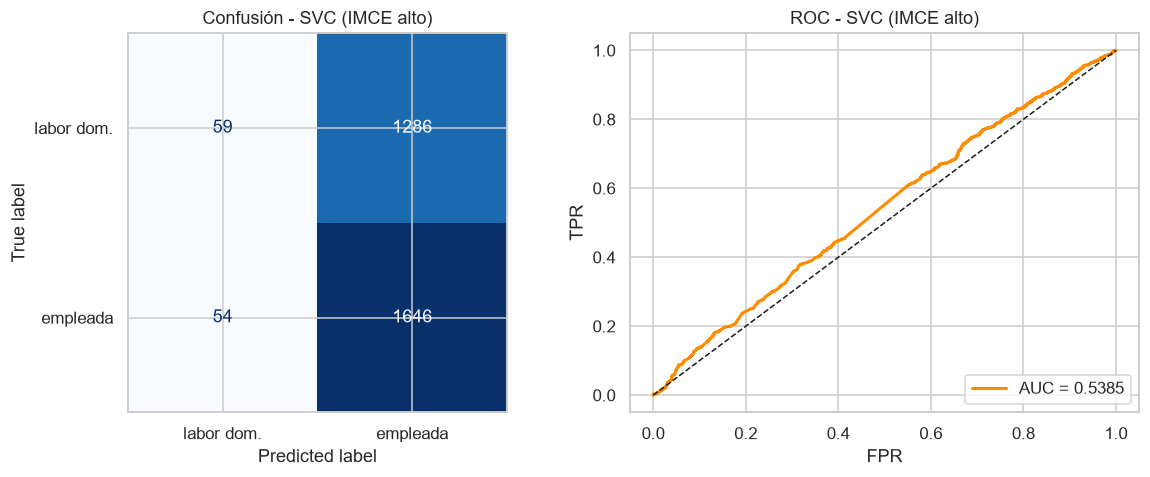

=== Muestra completa vs cluster IMCE alto ===
              contexto  accuracy      AUC
 Muestra completa (Q5)  0.552137 0.534371
Cluster IMCE alto (Q7)  0.559934 0.538509


In [30]:
from sklearn.base import clone

df_q7 = df[(df['cluster'] == cluster_imce_alto) & (df['madre_work'] != 0)].copy()
X_q7 = df_q7[features_cfa]
y_q7 = (df_q7['madre_work'] == 1).astype(int)
print(f'Submuestra Q7: n = {len(df_q7)}, % empleada = {y_q7.mean():.3f}')
print(f'Modelo a re-entrenar: {mejor_nombre}')

X_train_q7, X_test_q7, y_train_q7, y_test_q7 = train_test_split(
    X_q7, y_q7, test_size=0.20, stratify=y_q7, random_state=RANDOM_STATE)

modelo_q7 = clone(mejor_modelo)
t = time.time(); modelo_q7.fit(X_train_q7, y_train_q7); t_q7 = time.time() - t
pred_q7 = evaluar(f'{mejor_nombre} (IMCE alto)', modelo_q7, t_q7,
                  X_te=X_test_q7, y_te=y_test_q7)

res_q5 = [r for r in resultados if r['modelo'] == mejor_nombre][0]
res_q7 = resultados[-1]
print('=== Muestra completa vs cluster IMCE alto ===')
print(pd.DataFrame([
    {'contexto': 'Muestra completa (Q5)', 'accuracy': res_q5['accuracy'], 'AUC': res_q5['AUC']},
    {'contexto': 'Cluster IMCE alto (Q7)', 'accuracy': res_q7['accuracy'], 'AUC': res_q7['AUC']}
]).to_string(index=False))

Al volver a entrenar el modelo solo dentro del cluster de mayor IMCE, el resultado es prácticamente igual al de la muestra completa: el AUC casi no se mueve (queda alrededor de 0,54) y el accuracy sigue sin superar de verdad al baseline, con el modelo otra vez pegado a la clase mayoritaria.

Esto descarta una hipótesis razonable, que era que la muestra completa fuera muy mezclada y estuviera escondiendo una relación que sí aparecería en un grupo más parecido entre sí. Pero no: incluso achicando el análisis a niños con un perfil de peso similar, el perfil socioemocional sigue sin predecir la situación laboral de la madre. La explicación más simple es que estas dos cosas son independientes. Y tiene sentido si uno lo piensa: que una madre trabaje fuera de la casa depende sobre todo de factores económicos, de la oferta de trabajo o de decisiones familiares, no del nivel de curiosidad, afecto o juego del niño. Para predecir `madre_work` probablemente harían falta variables de otro tipo (ingresos, nivel educativo de la madre, acceso a sala cuna, etc.) que esta base no tiene.

## Pregunta 8

*Revise el notebook Sentiment_Analysis.ipynb. Considere la variable narrative en el dataset. Utilice las funciones para tokenizar los textos y luego entrene un modelo adecuado para contrastar con la Pregunta 5 (SVC), excluyendo las variables sk. Compare y discuta sus resultados.*

In [31]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

spanish_stops = set(stopwords.words('spanish'))

def limpiar_texto(texto):
    if not isinstance(texto, str):
        return ''
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto.lower())
    palabras = [w for w in texto.split() if w not in spanish_stops and len(w) > 2]
    return ' '.join(palabras)

modelo_df['narrative_clean'] = modelo_df['narrative'].apply(limpiar_texto)
print('Texto original:', modelo_df['narrative'].iloc[0][:200], '...')
print('Texto limpio:  ', modelo_df['narrative_clean'].iloc[0][:200], '...')
print(f'Textos procesados: {len(modelo_df)}')

Texto original: Las habilidades socioemocionales estan bien establecidas, con lo afectivo-emocional como area mas fuerte y la curiosidad e intereses cognitivos como la mas rezagada. Solo rara vez muestra agresividad. ...
Texto limpio:   habilidades socioemocionales estan bien establecidas afectivo emocional area mas fuerte curiosidad intereses cognitivos mas rezagada solo rara vez muestra agresividad destaca especialmente afecto haci ...
Textos procesados: 37545


El preprocesamiento del texto sigue los pasos típicos. Primero limpio cada narrativa: paso todo a minúsculas y saco los caracteres que no son letras. Después quito las stopwords del español (artículos, preposiciones y palabras muy comunes que no aportan significado). Por último vectorizo el texto con `CountVectorizer`, que arma una matriz donde cada columna es una palabra (o un par de palabras, porque uso unigramas y bigramas) y cada valor cuenta cuántas veces aparece esa palabra en la narrativa. Es un enfoque de bolsa de palabras, simple pero suficiente para comparar contra los factores.

Dimensión de la matriz doc-término: (30036, 500)
SVC-texto               acc=0.5408  AUC=0.5231  t_fit=5.63s
              precision    recall  f1-score   support

  labor dom.       0.49      0.22      0.30      3405
    empleada       0.55      0.81      0.66      4104

    accuracy                           0.54      7509
   macro avg       0.52      0.51      0.48      7509
weighted avg       0.52      0.54      0.50      7509



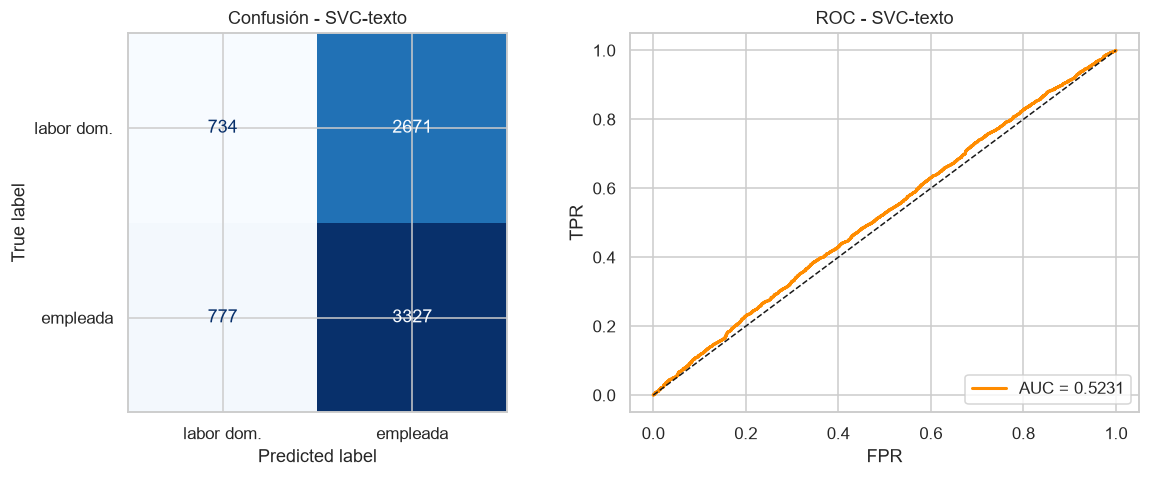

In [32]:
from sklearn.svm import LinearSVC
import time

vect = CountVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.95, max_features=500)
X_text_train = vect.fit_transform(modelo_df.loc[X_train.index, 'narrative_clean'])
X_text_test  = vect.transform(modelo_df.loc[X_test.index, 'narrative_clean'])
print(f'Dimensión de la matriz doc-término: {X_text_train.shape}')

svc_text = LinearSVC(random_state=RANDOM_STATE)
t = time.time(); svc_text.fit(X_text_train, y_train); t_text = time.time() - t
pred_text = evaluar('SVC-texto', svc_text, t_text, X_te=X_text_test, y_te=y_test)


In [33]:
res_svc_factores = [r for r in resultados if r['modelo'] == 'SVC'][0]
res_svc_texto    = [r for r in resultados if r['modelo'] == 'SVC-texto'][0]

comp_q8 = pd.DataFrame([
    {'representación': 'Factores CFA (Q5)',
     'n_features': len(features_cfa),
     'accuracy': res_svc_factores['accuracy'],
     'AUC': res_svc_factores['AUC'],
     't_fit_s': res_svc_factores['t_fit_s']},
    {'representación': 'Texto narrative (Q8)',
     'n_features': X_text_train.shape[1],
     'accuracy': res_svc_texto['accuracy'],
     'AUC': res_svc_texto['AUC'],
     't_fit_s': res_svc_texto['t_fit_s']}
])
print('=== SVC con factores vs SVC con texto ===')
print(comp_q8.to_string(index=False))

coef = pd.DataFrame({'término': vect.get_feature_names_out(), 'coef': svc_text.coef_[0]})
coef = coef.sort_values('coef', ascending=False)
print('\nTop 10 términos -> empleada:')
print(coef.head(10).to_string(index=False))
print('\nTop 10 términos -> labor doméstica:')
print(coef.tail(10).sort_values('coef').to_string(index=False))

=== SVC con factores vs SVC con texto ===
      representación  n_features  accuracy      AUC  t_fit_s
   Factores CFA (Q5)           3  0.552137 0.534371   37.183
Texto narrative (Q8)         500  0.540818 0.523118    5.630

Top 10 términos -> empleada:
                     término     coef
                  desarrollo 0.668651
                  estan bien 0.314399
           bien establecidas 0.314399
                        bien 0.314399
                establecidas 0.314399
socioemocional satisfactorio 0.217308
               satisfactorio 0.217308
 socioemocionales plenamente 0.212856
                consolidadas 0.212856
     plenamente consolidadas 0.212856

Top 10 términos -> labor doméstica:
                     término      coef
          muestra desarrollo -0.424890
   desarrollo socioemocional -0.343741
         presenta desarrollo -0.279981
         sentimientos siendo -0.248448
      socioemocionales estan -0.241353
                       estan -0.241353
                 

El modelo de texto vuelve a quedarse en el azar, con métricas parecidas o incluso un poco peores que el SVM sobre los factores (AUC de 0,52 contra 0,53). Tiene una explicación clara: la columna `narrative` es básicamente una versión escrita de los mismos ítems `sk`, generada a partir de ellos, así que no trae información nueva. Esto confirma desde otro lado lo que se vino repitiendo en todo el trabajo: el problema no es cómo represento los predictores (factores, texto, lo que sea), sino que la condición laboral de la madre simplemente no depende del perfil socioemocional del niño, al menos con los datos de esta base.

De paso, mirar los términos con más peso es entretenido: palabras como "desarrollo", "bien establecidas" o "consolidadas" empujan hacia "empleada", mientras que otras formas más neutras empujan hacia "labor doméstica". Pero los coeficientes son chicos y la diferencia entre clases es mínima, así que tampoco hay que leer demasiado ahí.

A lo largo del trabajo seguí un análisis completo, desde la limpieza de los datos hasta la clasificación y el clustering. El resultado más consistente, y para mí el más interesante, es que el perfil socioemocional de los niños no predice la situación laboral de sus madres, sin importar la técnica que use: ni Random Forest, ni XGBoost, ni SVM, ni Stacking le ganan al baseline, y eso se mantiene tanto en la muestra completa como dentro del grupo más homogéneo que armé con clustering.

Que el resultado sea negativo no significa que el trabajo haya fallado. Es un hallazgo válido: muestra que el mundo socioemocional del niño y la situación laboral de la madre son, en esta población, dos cosas básicamente independientes. Y sí hubo un resultado positivo por el lado del análisis factorial, que encontró una estructura clara de tres dimensiones socioemocionales (curiosidad cognitiva, vínculo afectivo e interacción social). Esa estructura tiene valor por sí sola para describir el desarrollo de los niños, aunque no sirva para predecir el target que elegí.